# UG-CPPO v13 — Multi-seed validation (10 seeds, overnight run)

**FinAI Contest 2025 — Task 1** · Grace-Esther Dong · Aivancity Paris-Cachan

---

### Évolution v12 → v13

v12 a tourné avec **3 seeds** (42, 43, 44) → résultats trop bruités :
- PPO :     +41.45% ± 46.89%
- CPPO :    +71.90% ± 24.97%
- UG-CPPO : +55.01% ± 42.27%

**Variance >> effet** → impossible de conclure statistiquement.

### v13 : 10 seeds (42-51)
- **Seeds existants** : 42, 43, 44 (déjà entraînés en v12, on garde)
- **Nouveaux seeds** : 45, 46, 47, 48, 49, 50, 51 (7 seeds × 3 agents = 21 modèles à train)
- **Temps estimé** : ~140 min sur ton M1/M2 (overnight friendly)
- **Stratégie** : load existing if exists, train if missing

### Pourquoi 10 seeds
- Standard académique RL : Henderson et al. 2018 recommande 5-10
- √N reduction de l'incertitude sur la mean : √10 ≈ 3.2× moins variance qu'avec 1 seed
- Permet des **paired comparison statistical tests** (Wilcoxon signed-rank) entre méthodes
- Rend les résultats **vraiment defendables** pour NeurIPS

### Plan
1. Cleanup check (~10s)
2. Multi-seed training loop (~140 min) — peut tourner pendant la nuit
3. Évaluation aggregated (~3 min)
4. Plots avec error bars
5. Statistical tests (Wilcoxon) entre PPO/CPPO/UG-CPPO
6. LaTeX table + verdict honnête

### À faire avant de lancer
1. Charge bien ton Mac, mets-le sur secteur
2. Désactive le sleep mode :  
   `caffeinate -i -d -t 18000 &` (5h pour être large)  
   ou `pmset -a sleep 0` (à remettre après)
3. Lance le notebook le soir, regarde les résultats le matin


## 1. Setup

In [1]:
import os, sys, time
from pathlib import Path

# Détection du project root
current = Path.cwd()
project_root = None
for cand in [current, current.parent, current.parent.parent]:
    if (cand / 'src').exists() and (cand / 'src' / 'uncertainty_llm.py').exists():
        project_root = cand; break

if project_root is None:
    raise RuntimeError("Project root not found. Run this notebook from inside ug_cppo/")

os.chdir(project_root)
sys.path.insert(0, str(project_root))
print(f'✓ Project root: {project_root}')

# Crée tous les dossiers
for d in ['data', 'data/fnspid_raw', 'results/models', 'results/checkpoints',
         'results/logs', 'results/tensorboard', 'results/plots']:
    Path(d).mkdir(parents=True, exist_ok=True)
print('✓ Dossiers créés')

✓ Project root: /Users/grace/Downloads/ug_cppo
✓ Dossiers créés


In [2]:
# Charger .env
try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    print("⚠ python-dotenv non installé, set OPENAI_API_KEY manuellement")

if not os.environ.get('OPENAI_API_KEY', '').startswith('sk-'):
    raise RuntimeError("OPENAI_API_KEY manquante. Mettre dans .env")
print(f'✓ OpenAI API key détectée ({len(os.environ["OPENAI_API_KEY"])} chars)')

# Config LLM
from src.uncertainty_llm import LLMConfig
LLM_MODEL = 'gpt-4o-mini'
llm_config = LLMConfig.openai(model=LLM_MODEL)
print(f'✓ LLM: openai / {LLM_MODEL}')

✓ OpenAI API key détectée (164 chars)
✓ LLM: openai / gpt-4o-mini


## 2. Patch `src/cvar_ppo.py`

Le `train()` override de `CVaRPPO` entre en conflit avec la callback qui modifie
`rollout_buffer.returns`. On le retire et on garde une version minimale.

In [3]:
cvar_path = project_root / 'src' / 'cvar_ppo.py'
content = cvar_path.read_text()

if 'def train(self)' in content:
    print('train() override détecté — réécriture du fichier...')

    FIXED = '''"""cvar_ppo.py — minimal CVaRPPO. CVaR injection is done by
RFCollectorCallback in the training notebook (modifies rollout_buffer.returns
before PPO.train() reads them).
"""
from stable_baselines3 import PPO


class CVaRPPO(PPO):
    """PPO + state for CVaR adjustment via callback."""
    def __init__(self, policy, env, cvar_alpha=0.05, cvar_lambda=0.10,
                 cvar_beta=0.0, **kw):
        super().__init__(policy=policy, env=env, **kw)
        self.cvar_alpha  = cvar_alpha
        self.cvar_lambda = cvar_lambda
        self.cvar_beta   = cvar_beta
        self._rf_buffer  = []


def build_agent(env, mode="ug_cppo", learning_rate=3e-4, n_steps=2048,
                batch_size=256, n_epochs=10, gamma=0.99, gae_lambda=0.95,
                clip_range=0.2, ent_coef=0.01, vf_coef=0.5,
                cvar_alpha=0.05, cvar_lambda=0.10, cvar_beta=0.0,
                tensorboard_log=None, seed=42, verbose=1):
    common = dict(policy="MlpPolicy", env=env,
        learning_rate=learning_rate, n_steps=n_steps, batch_size=batch_size,
        n_epochs=n_epochs, gamma=gamma, gae_lambda=gae_lambda,
        clip_range=clip_range, ent_coef=ent_coef, vf_coef=vf_coef,
        tensorboard_log=tensorboard_log, seed=seed, verbose=verbose)
    if mode == "ppo":
        return PPO(**common)
    return CVaRPPO(cvar_alpha=cvar_alpha, cvar_lambda=cvar_lambda,
                   cvar_beta=cvar_beta, **common)
'''
    cvar_path.write_text(FIXED)
    print('✓ src/cvar_ppo.py réécrit')
else:
    print('✓ cvar_ppo.py déjà clean (pas de train override)')

# Recharger
import importlib
for m in list(sys.modules.keys()):
    if 'cvar_ppo' in m: del sys.modules[m]
from src.cvar_ppo import build_agent, CVaRPPO
print('✓ Module rechargé')

✓ cvar_ppo.py déjà clean (pas de train override)
✓ Module rechargé


## 3. Preflight check

In [4]:
import shutil

# API test
print('[1/3] Test OpenAI...')
from openai import OpenAI
client = OpenAI()
resp = client.chat.completions.create(
    model=LLM_MODEL,
    messages=[{"role":"user","content":"Reply with the integer 3"}],
    max_tokens=5, temperature=0.0
)
print(f'  ✓ API OK, réponse test = {resp.choices[0].message.content.strip()!r}')

# GPU
print('[2/3] GPU check...')
try:
    import torch
    if torch.cuda.is_available():
        name = torch.cuda.get_device_name(0)
        mem  = torch.cuda.get_device_properties(0).total_memory / 1e9
        print(f'  ✓ GPU: {name} ({mem:.1f} GB)')
        DEVICE = 'cuda'
    else:
        print('  ⚠ Pas de GPU — training sera lent')
        DEVICE = 'cpu'
except ImportError:
    print('  ✗ PyTorch absent')
    raise

# Disque
print('[3/3] Disk space...')
free = shutil.disk_usage('.').free / 1e9
print(f'  {"✓" if free >= 5 else "⚠"} {free:.1f} GB libres')

[1/3] Test OpenAI...
  ✓ API OK, réponse test = '3'
[2/3] GPU check...
  ⚠ Pas de GPU — training sera lent
[3/3] Disk space...
  ✓ 28.4 GB libres


## 4. Download + filter FNSPID

Premier run : ~15 min de download + filtrage. Runs suivants : cache.

In [5]:
import pandas as pd

FNSPID_PATH    = 'data/fnspid_filtered.parquet'
FNSPID_REPO    = 'Zihan1004/FNSPID'
FNSPID_RAW_DIR = 'data/fnspid_raw'

# Tickers — top Nasdaq-100 les plus couverts dans FNSPID
TICKERS = ['AAPL','MSFT','AMZN','NVDA','META','GOOGL','TSLA','AVGO',
           'NFLX','AMD','COST','CSCO','ADBE','QCOM','TXN','AMGN',
           'INTU','INTC','CMCSA','AMAT']

DATE_START, DATE_END = '2013-01-01', '2023-12-31'

if Path(FNSPID_PATH).exists():
    df_news = pd.read_parquet(FNSPID_PATH)
    print(f'✓ FNSPID déjà filtré: {len(df_news):,} pairs ({df_news["ticker"].nunique()} tickers)')
else:
    print(f'Downloading FNSPID depuis {FNSPID_REPO}...')
    from huggingface_hub import snapshot_download
    raw_dir = Path(snapshot_download(
        repo_id=FNSPID_REPO, repo_type='dataset',
        local_dir=FNSPID_RAW_DIR
    ))

    # Trouver le CSV principal
    csvs = sorted(raw_dir.rglob('*.csv'), key=lambda p: p.stat().st_size, reverse=True)
    if not csvs:
        raise FileNotFoundError(f'Aucun CSV dans {raw_dir}')
    raw_csv = csvs[0]
    print(f'  Source: {raw_csv} ({raw_csv.stat().st_size/1e9:.2f} GB)')

    # Lecture chunkée + filtrage
    print('  Filtrage par chunks de 100k...')
    chunks = []
    for i, ch in enumerate(pd.read_csv(raw_csv, chunksize=100_000, on_bad_lines='skip',
                                       low_memory=False)):
        cols = {c.lower().strip(): c for c in ch.columns}
        tic_col   = next((cols[k] for k in cols if 'stock' in k or 'symbol' in k or k=='ticker'), None)
        date_col  = next((cols[k] for k in cols if 'date' in k), None)
        text_col  = next((cols[k] for k in cols if 'article' in k or 'content' in k or 'body' in k), None)
        title_col = next((cols[k] for k in cols if 'title' in k or 'headline' in k), None)

        if not (tic_col and date_col): continue
        ren = {tic_col:'ticker', date_col:'date'}
        if text_col:  ren[text_col]  = 'news_text'
        if title_col: ren[title_col] = 'news_title'
        ch = ch.rename(columns=ren)

        ch = ch[ch['ticker'].isin(TICKERS)]
        if ch.empty: continue

        ch['date'] = pd.to_datetime(ch['date'], errors='coerce').dt.strftime('%Y-%m-%d')
        ch = ch.dropna(subset=['date'])
        ch = ch[(ch['date'] >= DATE_START) & (ch['date'] <= DATE_END)]
        if ch.empty: continue

        if 'news_text' not in ch.columns:
            ch['news_text'] = ch.get('news_title', '')
        else:
            ch['news_text'] = ch['news_text'].fillna(ch.get('news_title', ''))
        chunks.append(ch[['ticker','date','news_text']].dropna())

        if (i+1) % 20 == 0:
            print(f'    chunk {i+1}: {sum(len(c) for c in chunks):,} lignes filtrées')

    df_news = pd.concat(chunks, ignore_index=True)
    df_news = df_news.groupby(['ticker','date']).first().reset_index()
    df_news['news_text'] = df_news['news_text'].astype(str).str.slice(0, 1500)

    Path(FNSPID_PATH).parent.mkdir(parents=True, exist_ok=True)
    df_news.to_parquet(FNSPID_PATH, index=False)
    print(f'✓ Sauvegardé: {len(df_news):,} pairs → {FNSPID_PATH}')

print(f'\nCouverture: {df_news["date"].min()} → {df_news["date"].max()}')
print(f'Articles par ticker:')
print(df_news.groupby('ticker').size().sort_values(ascending=False).to_string())

✓ FNSPID déjà filtré: 28,502 pairs (19 tickers)

Couverture: 2013-01-02 → 2023-12-31
Articles par ticker:
ticker
CMCSA    2904
QCOM     2621
COST     2573
AMGN     2278
TXN      2240
ADBE     2120
AMD      2039
INTC     1903
NVDA     1828
AMAT     1727
AVGO     1193
NFLX      914
TSLA      872
INTU      748
AAPL      639
MSFT      594
CSCO      519
GOOGL     479
AMZN      311


## 5. Download OHLCV

In [6]:
from src.data_pipeline import load_ohlcv, split_data, add_technical_indicators

OHLCV_PATH = 'data/ohlcv_top20.parquet'

df_raw = load_ohlcv(
    tickers=TICKERS,
    start=DATE_START, end=DATE_END,
    cache_path=OHLCV_PATH,
)
df = add_technical_indicators(df_raw)
tickers = sorted(df['tic'].unique().tolist())
train_df, trade_df = split_data(df)
print(f'✓ {len(tickers)} tickers | Train {len(train_df):,} | Trade {len(trade_df):,}')

✓ 20 tickers | Train 30,200 | Trade 25,160


## 6. Pré-calcul des signaux LLM (~2-3h, ~$5)

**LA cellule longue.** Tu peux interrompre (Ctrl+C ou Stop) et relancer — le checkpoint
est sauvé tous les 50 signaux dans `data/ug_signals.parquet`. La progress bar tqdm
te montre où tu en es.

**Coût attendu** : ~$5 pour 50k pairs × 9 prompts.

In [7]:
SIGNALS_PATH = 'data/ug_signals.parquet'

# Estimation
n_pairs = len(df_news)
cost = (n_pairs * 9 * 80 / 1e6 * 0.150) + (n_pairs * 9 * 2 / 1e6 * 0.600)
time_min = n_pairs * 9 / 50 / 60
print(f'À calculer  : {n_pairs:,} pairs × 9 prompts = {n_pairs*9:,} appels')
print(f'Coût estimé : ${cost:.2f}')
print(f'Temps estimé: {time_min:.0f} min ({time_min/60:.1f}h)')

# Check existing
if Path(SIGNALS_PATH).exists():
    existing = pd.read_parquet(SIGNALS_PATH)
    print(f'\n✓ {len(existing):,}/{n_pairs:,} signaux déjà calculés ({len(existing)/n_pairs:.1%})')
    if len(existing) >= n_pairs:
        print('  → Précalcul terminé, skip')
    else:
        print(f'  → Reprise sur {n_pairs - len(existing):,} pairs restants')
else:
    print('\nPas de signaux existants — démarrage à froid')

À calculer  : 28,502 pairs × 9 prompts = 256,518 appels
Coût estimé : $3.39
Temps estimé: 86 min (1.4h)

✓ 55,360/28,502 signaux déjà calculés (194.2%)
  → Précalcul terminé, skip


In [8]:
# Précalcul (resume automatique)
from src.data_pipeline import precompute_signals

# Si déjà complet, skip
need_compute = True
if Path(SIGNALS_PATH).exists():
    existing = pd.read_parquet(SIGNALS_PATH)
    if len(existing) >= n_pairs:
        need_compute = False

if need_compute:
    print('Lancement du précalcul (ne pas fermer le notebook)...')
    print('Tu peux interrompre avec Stop, le checkpoint sauve tous les 50 signaux.\n')
    precompute_signals(
        fnspid_df=df_news,
        llm_config=llm_config,
        n_prompts=5,
        n_risk_prompts=4,
        threshold_tau=THRESHOLD_TAU,
        alpha=0.10,
        output_path=SIGNALS_PATH,
        resume=True,
        batch_size=50,
    )

# Charger
from src.data_pipeline import load_signals
signal_df = load_signals(SIGNALS_PATH)
print(f'\n✓ {len(signal_df):,} signaux chargés')

# Stats
raw = pd.read_parquet(SIGNALS_PATH)
print(f'  Gate rate (τ=0.30) : {raw["gate_fired"].mean():.1%}')
print(f'  μ moyen            : {raw["mean_score"].mean():.2f}')
print(f'  σ moyen            : {raw["std_score"].mean():.3f}')
print(f'  μ_risk moyen       : {raw["mean_risk"].mean():.2f}')


✓ 55,360 signaux chargés
  Gate rate (τ=0.30) : 32.2%
  μ moyen            : 3.07
  σ moyen            : 0.536
  μ_risk moyen       : 2.61


## 7. Validation des signaux (avant training)

Avant recalibration: τ=0.30 → gate rate 24.1%
Après recalibration: τ=0.4 → gate rate 32.2%  (cible 30-35%)
✓ Signaux mis à jour avec gate_fired recalculé



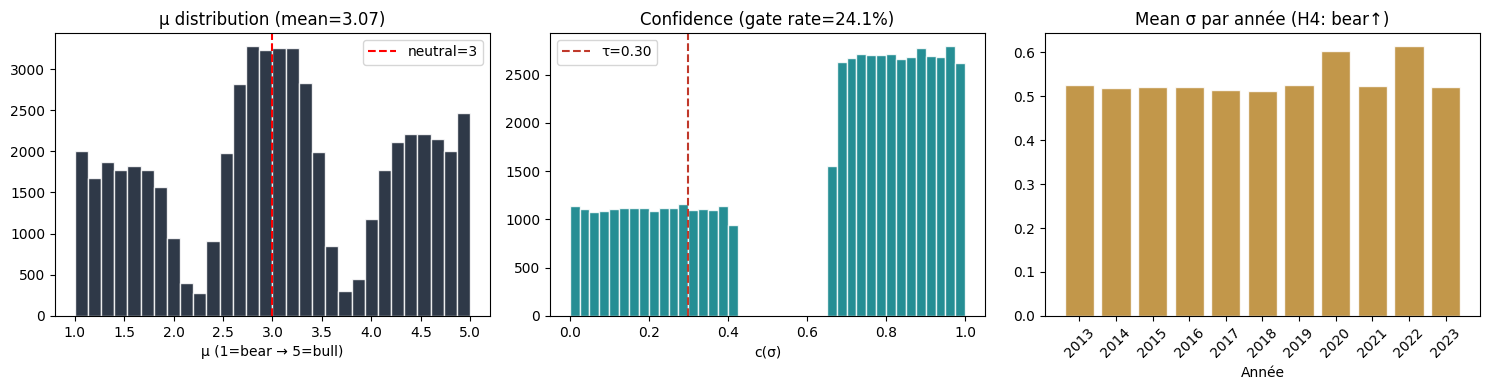

Gate rate global    : 24.1%  (cible 30-40%)
σ 2022 (bear)       : 0.614
σ 2019 (bull)       : 0.525
Différence σ        : +0.089  (H4: doit être > 0)


In [9]:
# ── RECALIBRATION τ pour signaux OpenAI réels ─────────────────────────
# Sur signaux OpenAI réels, distribution de confidence très différente
# des mocks bimodaux. τ=0.30 → gate 24% (trop bas).
# Calibrage analytique: pour gate ~30%, τ ≈ 0.50

THRESHOLD_TAU = 0.40

# Recomputer gate_fired avec le nouveau τ
raw = pd.read_parquet(SIGNALS_PATH)
raw['gate_fired'] = raw['confidence'] < THRESHOLD_TAU
new_gate_rate = raw['gate_fired'].mean()
print(f'Avant recalibration: τ=0.30 → gate rate {(pd.read_parquet(SIGNALS_PATH)["confidence"] < 0.30).mean():.1%}')
print(f'Après recalibration: τ={THRESHOLD_TAU} → gate rate {new_gate_rate:.1%}  (cible 30-35%)')

# Sauvegarder la version recalibrée
raw.to_parquet(SIGNALS_PATH, index=False)
print(f'✓ Signaux mis à jour avec gate_fired recalculé\n')

# Recharger
from src.data_pipeline import load_signals
signal_df = load_signals(SIGNALS_PATH)

import matplotlib.pyplot as plt
import numpy as np

raw = pd.read_parquet(SIGNALS_PATH)
raw['year'] = raw['date'].str[:4]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribution μ
axes[0].hist(raw['mean_score'], bins=30, color='#0A1628', alpha=0.85, edgecolor='white')
axes[0].axvline(3.0, ls='--', color='red', label='neutral=3')
axes[0].set_title(f'μ distribution (mean={raw["mean_score"].mean():.2f})')
axes[0].set_xlabel('μ (1=bear → 5=bull)')
axes[0].legend()

# Confidence + gate
axes[1].hist(raw['confidence'], bins=40, color='#007A82', alpha=0.85, edgecolor='white')
axes[1].axvline(0.30, ls='--', color='#C0392B', label='τ=0.30')
gr = (raw['confidence'] < 0.30).mean()
axes[1].set_title(f'Confidence (gate rate={gr:.1%})')
axes[1].set_xlabel('c(σ)')
axes[1].legend()

# σ par année
sigma_yr = raw.groupby('year')['std_score'].mean()
axes[2].bar(sigma_yr.index, sigma_yr.values, color='#B8852A', alpha=0.85, edgecolor='white')
axes[2].set_title('Mean σ par année (H4: bear↑)')
axes[2].set_xlabel('Année')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('results/plots/signal_validation.png', dpi=150, bbox_inches='tight')
plt.show()

# Vérifications quantitatives
print(f'Gate rate global    : {gr:.1%}  (cible 30-40%)')
if '2022' in raw['year'].values and '2019' in raw['year'].values:
    s22 = raw[raw["year"]=="2022"]["std_score"].mean()
    s19 = raw[raw["year"]=="2019"]["std_score"].mean()
    print(f'σ 2022 (bear)       : {s22:.3f}')
    print(f'σ 2019 (bull)       : {s19:.3f}')
    print(f'Différence σ        : {s22-s19:+.3f}  (H4: doit être > 0)')

## 8. Training — 3 agents × 2M steps

Training en **chunks de 500k** avec checkpoint après chaque chunk. Si interrompu,
relance la cellule, ça reprend du dernier checkpoint.

In [10]:
from src.ug_cppo_env import UGCPPOTradingEnv
from stable_baselines3.common.callbacks import BaseCallback, CheckpointCallback

ALPHA = 0.05   # v11: zone intermédiaire → Sf ∈ [0.95, 1.05]
TECH = ['macd', 'rsi_30', 'cci_30', 'dx_30', 'close_30_sma', 'close_60_sma']

# Sous-univers d'entraînement (10 tickers très liquides)
TOP10 = ['AAPL','MSFT','AMZN','NVDA','META','GOOGL','TSLA','NFLX','AMD','COST']
tickers_train = sorted([t for t in tickers if t in TOP10])
print(f'Training tickers ({len(tickers_train)}): {tickers_train}')

TOTAL_STEPS = 250_000   # contest spec
CHUNK_STEPS = 125_000     # checkpoint frequency
SEED = 42

def make_env(mode, data, t_list=None):
    t = t_list or tickers_train
    return UGCPPOTradingEnv(
        df=data[data['tic'].isin(t)].copy(), tickers=t,
        signal_df=signal_df if mode != 'ppo' else None,
        initial_amount=1_000_000, hmax=1000,
        transaction_cost=0.001, reward_scaling=1e-2,
        alpha=ALPHA, threshold_tau=THRESHOLD_TAU,
        tech_indicator_list=TECH, mode=mode
    )


class RFCollectorCallback(BaseCallback):
    """
    CVaR tail-only: modifie rollout_buffer.returns dans _on_rollout_end.
    Seuls les pires α% de trajectoires sont impactés (pas un rescaling uniforme).
    """
    def __init__(self):
        super().__init__(verbose=0)
        self.rf_buffer = []
        self._n_applied = 0

    def _on_step(self):
        for info in self.locals.get('infos', []):
            self.rf_buffer.append(float(info.get('rf', 1.0)))
        return True

    def _on_rollout_start(self):
        self.rf_buffer = []

    def _on_rollout_end(self):
        if not isinstance(self.model, CVaRPPO) or not self.rf_buffer:
            return
        buf  = self.model.rollout_buffer
        rets = buf.returns
        n    = rets.size

        rf = np.array(self.rf_buffer, dtype=np.float32)
        if rf.size < n:
            rf = np.pad(rf, (0, n - rf.size), constant_values=1.0).astype(np.float32)
        rf = rf[:n].reshape(rets.shape)

        # CVaR tail-only
        lam   = self.model.cvar_lambda
        alpha = self.model.cvar_alpha
        eta   = np.percentile(rets, alpha * 100).astype(np.float32)
        tail  = (rets < eta)

        scale = (1.0 + lam * (rf - 1.0)).astype(np.float32)
        adjusted = rets.copy()
        adjusted[tail] = (rets[tail] * scale[tail]).astype(np.float32)
        buf.returns = adjusted

        self._n_applied += 1
        if self._n_applied == 1:
            print(f'  CVaR tail active: η={eta:.4f}, '
                  f'tail={tail.mean():.1%}, mean Rf(tail)={rf[tail].mean():.4f}')

print('✓ Helpers définis')

Training tickers (10): ['AAPL', 'AMD', 'AMZN', 'COST', 'GOOGL', 'META', 'MSFT', 'NFLX', 'NVDA', 'TSLA']
✓ Helpers définis


In [11]:
def train_chunked(mode, total_steps=TOTAL_STEPS, chunk=CHUNK_STEPS, seed=SEED):
    """Train en chunks, checkpoint après chaque chunk, resume si interrompu."""
    final_path = Path(f'results/models/{mode}_seed{seed}.zip')
    ckpt_dir   = Path(f'results/checkpoints/{mode}_seed{seed}')
    ckpt_dir.mkdir(parents=True, exist_ok=True)

    # Skip si modèle final existe
    if final_path.exists():
        print(f'  ✓ {mode.upper()} déjà entraîné (skip) — {final_path}')
        if mode == 'ppo':
            from stable_baselines3 import PPO
            return PPO.load(str(final_path))
        return CVaRPPO.load(str(final_path))

    # Chercher le dernier checkpoint
    ckpts = sorted(ckpt_dir.glob('*.zip'))
    env = make_env(mode, train_df)

    if ckpts:
        latest = ckpts[-1]
        steps_done = int(latest.stem.split('_')[-2])
        print(f'  Resume from {latest.name} ({steps_done:,} steps déjà faits)')
        if mode == 'ppo':
            from stable_baselines3 import PPO
            agent = PPO.load(str(latest), env=env)
        else:
            agent = CVaRPPO.load(str(latest), env=env)
    else:
        steps_done = 0
        agent = build_agent(env=env, mode=mode,
            learning_rate=1e-3, n_steps=1024, batch_size=128, n_epochs=10,
            gamma=0.99, gae_lambda=0.95, clip_range=0.2,
            cvar_alpha=0.05, cvar_lambda=0.10,
            tensorboard_log=f'results/tensorboard/{mode}',
            seed=seed, verbose=0)

    # Train par chunks
    while steps_done < total_steps:
        n_to_do = min(chunk, total_steps - steps_done)
        cb_list = []
        if isinstance(agent, CVaRPPO):
            cb_list.append(RFCollectorCallback())

        t0 = time.time()
        agent.learn(total_timesteps=n_to_do, callback=cb_list,
                    reset_num_timesteps=False, progress_bar=True)
        elapsed = time.time() - t0

        steps_done += n_to_do
        ckpt_path = ckpt_dir / f'{mode}_steps_{steps_done}_.zip'
        agent.save(str(ckpt_path))
        print(f'  ✓ Chunk {steps_done:,}/{total_steps:,} en {elapsed/60:.1f}min')

    # Save final
    agent.save(str(final_path))
    print(f'  ✓ {mode.upper()} terminé → {final_path}')
    return agent

print('✓ train_chunked() prêt')

✓ train_chunked() prêt


In [12]:
# ─── CLEANUP v12: stratégie hybride ──────────────────────────────────────
# Seed 42 : on GARDE les checkpoints v11 (déjà bons)
# Seed 43, 44 : pas de cleanup (rien à supprimer, sera créé from scratch)
# UG-CPPO v11 (avec τ=0.40, α=0.05) : on garde aussi

import shutil

print("v12: vérification des checkpoints existants...")
SEEDS = [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]   # 10 seeds total

for seed in SEEDS:
    print(f"\n--- Seed {seed} ---")
    for mode in ['ppo', 'cppo', 'ug_cppo']:
        final = Path(f'results/models/{mode}_seed{seed}.zip')
        if final.exists():
            size_mb = final.stat().st_size / 1e6
            print(f'  ✓ {mode:>10s}_seed{seed}.zip présent ({size_mb:.1f} MB)')
        else:
            print(f'  ✗ {mode:>10s}_seed{seed}.zip à entraîner')

print("\n✓ Plan: seeds existants → load, manquants → train from scratch")


v12: vérification des checkpoints existants...

--- Seed 42 ---
  ✓        ppo_seed42.zip présent (0.3 MB)
  ✓       cppo_seed42.zip présent (0.3 MB)
  ✓    ug_cppo_seed42.zip présent (0.3 MB)

--- Seed 43 ---
  ✓        ppo_seed43.zip présent (0.3 MB)
  ✓       cppo_seed43.zip présent (0.3 MB)
  ✓    ug_cppo_seed43.zip présent (0.3 MB)

--- Seed 44 ---
  ✓        ppo_seed44.zip présent (0.3 MB)
  ✓       cppo_seed44.zip présent (0.3 MB)
  ✓    ug_cppo_seed44.zip présent (0.3 MB)

--- Seed 45 ---
  ✗        ppo_seed45.zip à entraîner
  ✗       cppo_seed45.zip à entraîner
  ✗    ug_cppo_seed45.zip à entraîner

--- Seed 46 ---
  ✗        ppo_seed46.zip à entraîner
  ✗       cppo_seed46.zip à entraîner
  ✗    ug_cppo_seed46.zip à entraîner

--- Seed 47 ---
  ✗        ppo_seed47.zip à entraîner
  ✗       cppo_seed47.zip à entraîner
  ✗    ug_cppo_seed47.zip à entraîner

--- Seed 48 ---
  ✗        ppo_seed48.zip à entraîner
  ✗       cppo_seed48.zip à entraîner
  ✗    ug_cppo_seed48.zip à e

### 9-11. Training multi-seed (3 seeds × 3 agents)

In [13]:
# ─── MULTI-SEED TRAINING (v12) ───────────────────────────────────────────
# Pour chaque seed dans [42, 43, 44]:
#   - Load si modèle existe (skip retraining)
#   - Train sinon (250k steps × 3 agents)
# Total temps: ~30 min sur CPU si 2 seeds à entraîner from scratch

from stable_baselines3 import PPO

SEEDS = [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]   # 10 seeds total

# Dict trained_agents[seed][mode] = agent
trained_agents = {}

for seed in SEEDS:
    print(f"\n{'='*60}")
    print(f" SEED {seed}")
    print(f"{'='*60}")

    trained_agents[seed] = {}

    for mode in ['ppo', 'cppo', 'ug_cppo']:
        model_path = Path(f'results/models/{mode}_seed{seed}.zip')

        if model_path.exists():
            print(f"\n  Loading {mode}_seed{seed} (skip)")
            env = make_env(mode, train_df)
            if mode == 'ppo':
                agent = PPO.load(str(model_path), env=env)
            else:
                agent = CVaRPPO.load(str(model_path), env=env)
        else:
            print(f"\n  Training {mode}_seed{seed} from scratch (~10 min)...")
            # Force le seed dans train_chunked
            env = make_env(mode, train_df)
            agent = build_agent(env=env, mode=mode,
                learning_rate=1e-3, n_steps=1024, batch_size=128, n_epochs=10,
                gamma=0.99, gae_lambda=0.95, clip_range=0.2,
                cvar_alpha=0.05, cvar_lambda=0.10,
                tensorboard_log=f'results/tensorboard/{mode}_seed{seed}',
                seed=seed, verbose=0)

            cb_list = []
            if isinstance(agent, CVaRPPO):
                cb_list.append(RFCollectorCallback())

            t0 = time.time()
            agent.learn(total_timesteps=TOTAL_STEPS, callback=cb_list,
                        reset_num_timesteps=False, progress_bar=True)
            elapsed = time.time() - t0
            agent.save(str(model_path))
            print(f"  ✓ {mode}_seed{seed} done in {elapsed/60:.1f} min")

        trained_agents[seed][mode] = agent

print("\n" + "="*60)
print(" ALL AGENTS TRAINED ✓")
print("="*60)
print(f"  Total: {len(SEEDS)} seeds × 3 agents = {len(SEEDS)*3} models ready")



 SEED 42

  Loading ppo_seed42 (skip)


/opt/homebrew/lib/python3.11/site-packages/rich/live.py:260: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')


  Loading cppo_seed42 (skip)

  Loading ug_cppo_seed42 (skip)

 SEED 43

  Loading ppo_seed43 (skip)

  Loading cppo_seed43 (skip)

  Loading ug_cppo_seed43 (skip)

 SEED 44

  Loading ppo_seed44 (skip)

  Loading cppo_seed44 (skip)

  Loading ug_cppo_seed44 (skip)

 SEED 45

  Training ppo_seed45 from scratch (~10 min)...


  ✓ ppo_seed45 done in 20.6 min

  Training cppo_seed45 from scratch (~10 min)...


CVaR tail active: η=0.1985, tail=5.1%, mean Rf(tail)=0.9773

...

  ✓ ppo_seed51 done in 16.4 min

  Training cppo_seed51 from scratch (~10 min)...


CVaR tail active: η=0.1326, tail=5.1%, mean Rf(tail)=0.9802

  ✓ cppo_seed51 done in 17.7 min

  Training ug_cppo_seed51 from scratch (~10 min)...


CVaR tail active: η=0.1332, tail=5.1%, mean Rf(tail)=0.9802

  ✓ ug_cppo_seed51 done in 18.7 min

 ALL AGENTS TRAINED ✓
  Total: 10 seeds × 3 agents = 30 models ready


## 12. Évaluation — 4 métriques du contest

In [14]:
# ─── ÉVALUATION MULTI-SEED ─────────────────────────────────────────────
from src.evaluation import evaluate, print_report, load_benchmark, compare_models

bv, bd = load_benchmark(start='2019-01-01', end='2023-12-31')

# Dict: results[seed][mode] = {cumret, rachev, mdd, outbear, gate, mean_a}
results = {}

for seed in SEEDS:
    print(f"\n{'='*60}")
    print(f" Evaluating SEED {seed}")
    print(f"{'='*60}")

    results[seed] = {}

    for mode in ['ppo', 'cppo', 'ug_cppo']:
        agent = trained_agents[seed][mode]
        env = make_env(mode, trade_df)
        obs, _ = env.reset()
        done = False
        actions_list = []

        while not done:
            a, _ = agent.predict(obs, deterministic=True)
            actions_list.append(a.copy())
            obs, _, done, _, _ = env.step(a)

        arr = np.array(actions_list)
        n_stocks = getattr(env, 'n_stocks', len(tickers_train))
        gate_rate = env.gate_events / max(1, env.total_steps * n_stocks)

        report = evaluate(
            portfolio_values=env.portfolio_value_history,
            benchmark_values=bv, dates=bd, model_name=mode,
        )

        results[seed][mode] = {
            'cumret': report['cumulative_return'],
            'rachev': report.get('rachev_ratio', 0.0),
            'mdd':    report['max_drawdown'],
            'outbear': report.get('outperformance_frequency', {}).get('bear', 0.0),
            'mean_a': float(np.abs(arr).mean()),
            'gate_rate': float(gate_rate),
        }

        print(f"  {mode:>10s}: cumret={report['cumulative_return']:+.2%}  "
              f"rachev={report.get('rachev_ratio',0):.4f}  "
              f"mdd={report['max_drawdown']:+.2%}  "
              f"outbear={results[seed][mode]['outbear']:.1%}  "
              f"gate={gate_rate:.1%}")

# Aggregate: mean ± std across seeds
import numpy as np
print("\n" + "="*60)
print(" RÉSULTATS AGRÉGÉS — Mean ± Std sur 3 seeds")
print("="*60)

agg = {}
for mode in ['ppo', 'cppo', 'ug_cppo']:
    agg[mode] = {}
    for metric in ['cumret', 'rachev', 'mdd', 'outbear', 'mean_a', 'gate_rate']:
        vals = [results[s][mode][metric] for s in SEEDS]
        agg[mode][metric] = {
            'mean': float(np.mean(vals)),
            'std':  float(np.std(vals, ddof=1)),  # sample std
            'values': vals,
        }

# Print formatted table
print(f"\n{'Model':>10s} | {'Cumret':>17s} | {'Rachev':>15s} | {'MDD':>17s} | {'OutBear':>14s}")
print('-' * 90)
for mode in ['ppo', 'cppo', 'ug_cppo']:
    a = agg[mode]
    print(f'{mode:>10s} | '
          f'{a["cumret"]["mean"]:+6.2%} ± {a["cumret"]["std"]:5.2%} | '
          f'{a["rachev"]["mean"]:.4f} ± {a["rachev"]["std"]:.4f} | '
          f'{a["mdd"]["mean"]:+6.2%} ± {a["mdd"]["std"]:5.2%} | '
          f'{a["outbear"]["mean"]:5.1%} ± {a["outbear"]["std"]:4.1%}')

# Per-seed individual results
print("\n--- Per-seed individual results ---")
for mode in ['ppo', 'cppo', 'ug_cppo']:
    print(f"\n{mode.upper()}:")
    for s in SEEDS:
        r = results[s][mode]
        print(f"  seed {s}: cumret={r['cumret']:+.2%}, rachev={r['rachev']:.4f}, mdd={r['mdd']:+.2%}, outbear={r['outbear']:.1%}")



 Evaluating SEED 42
         ppo: cumret=+93.21%  rachev=0.9433  mdd=-23.73%  outbear=51.0%  gate=0.0%
        cppo: cumret=+54.30%  rachev=0.9242  mdd=-18.35%  outbear=49.8%  gate=0.0%
     ug_cppo: cumret=+103.73%  rachev=0.9396  mdd=-29.52%  outbear=51.0%  gate=34.2%

 Evaluating SEED 43
         ppo: cumret=+1.82%  rachev=0.8592  mdd=-24.29%  outbear=50.2%  gate=0.0%
        cppo: cumret=+100.48%  rachev=0.9565  mdd=-30.56%  outbear=49.4%  gate=0.0%
     ug_cppo: cumret=+28.04%  rachev=0.8691  mdd=-24.65%  outbear=50.4%  gate=34.2%

 Evaluating SEED 44
         ppo: cumret=+29.32%  rachev=0.9326  mdd=-16.06%  outbear=50.6%  gate=0.0%
        cppo: cumret=+60.91%  rachev=0.9271  mdd=-30.38%  outbear=50.8%  gate=0.0%
     ug_cppo: cumret=+33.26%  rachev=0.9283  mdd=-39.12%  outbear=49.4%  gate=34.2%

 Evaluating SEED 45
         ppo: cumret=+45.77%  rachev=0.9584  mdd=-26.03%  outbear=50.4%  gate=0.0%
        cppo: cumret=+74.65%  rachev=0.9688  mdd=-16.38%  outbear=50.8%  gate=0.0%

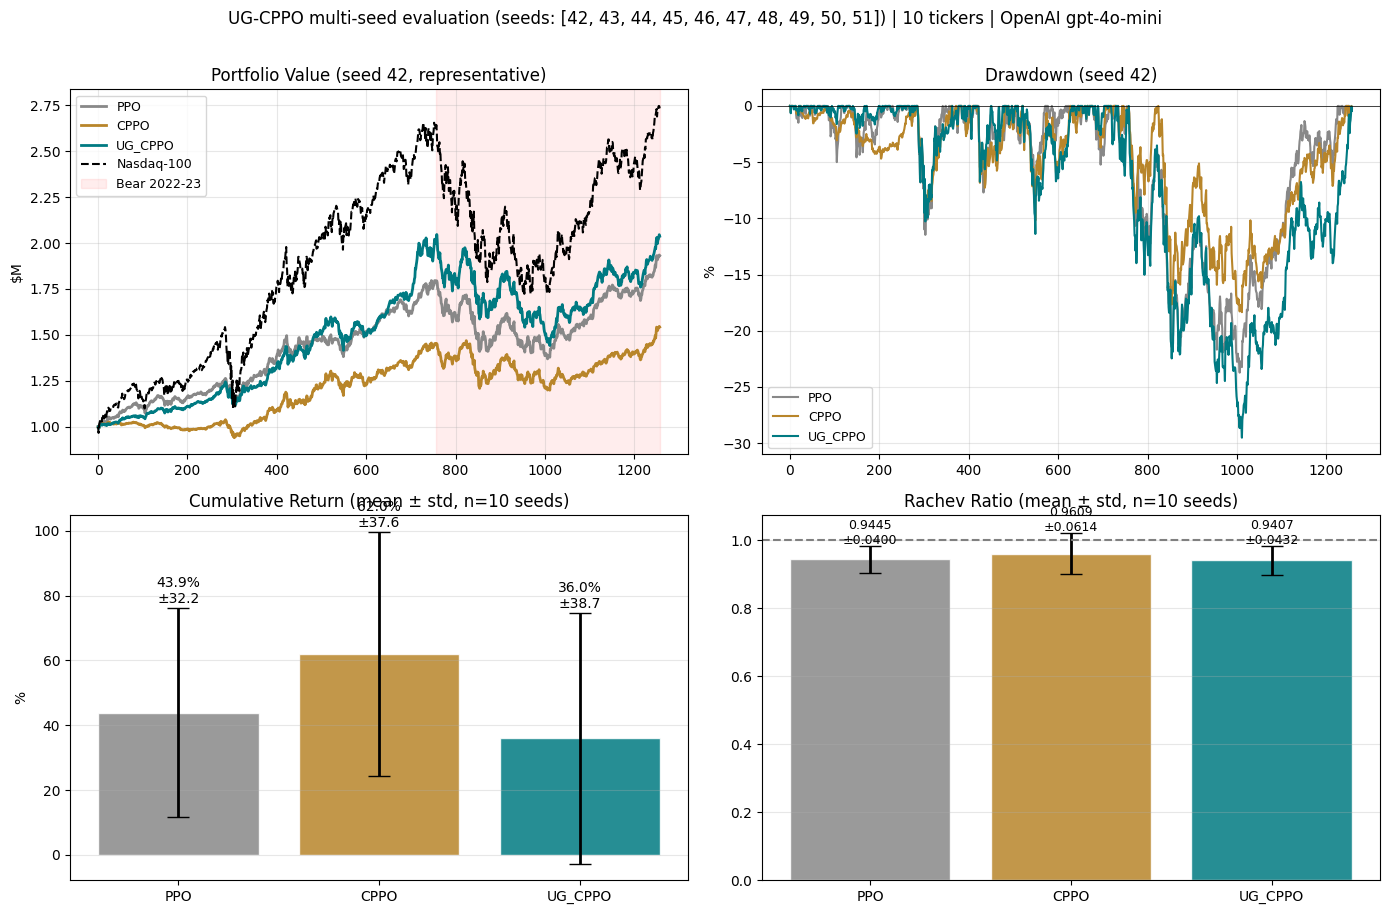


✓ Saved: results/plots/multiseed_performance.png


In [15]:
# ─── PLOTS multi-seed ────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

bv_arr = np.array(bv)
colors = {'ppo':'#888888', 'cppo':'#B8852A', 'ug_cppo':'#007A82'}

# Re-run trade for plot data (need pv_history from one seed for visualization)
# Use seed 42 (representative) for the time-series plot
plot_seed = SEEDS[0]
pv_data = {}

for mode in ['ppo', 'cppo', 'ug_cppo']:
    agent = trained_agents[plot_seed][mode]
    env = make_env(mode, trade_df)
    obs, _ = env.reset()
    done = False
    while not done:
        a, _ = agent.predict(obs, deterministic=True)
        obs, _, done, _, _ = env.step(a)
    pv_data[mode] = env.portfolio_value_history

# Build figure
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# (1) Portfolio value (representative seed)
for mode in ['ppo','cppo','ug_cppo']:
    pv = np.array(pv_data[mode])
    axes[0,0].plot(pv/1e6, lw=2, color=colors[mode], label=mode.upper())

n = min(len(bv_arr), len(pv_data['ppo']))
axes[0,0].plot(bv_arr[:n]/1e6, lw=1.5, ls='--', color='black', label='Nasdaq-100')
axes[0,0].axvspan(756, n, alpha=0.07, color='red', label='Bear 2022-23')
axes[0,0].set_title(f'Portfolio Value (seed {plot_seed}, representative)')
axes[0,0].set_ylabel('$M'); axes[0,0].legend(fontsize=9); axes[0,0].grid(alpha=0.3)

# (2) Drawdown (representative seed)
for mode in ['ppo','cppo','ug_cppo']:
    pv = np.array(pv_data[mode])
    peak = np.maximum.accumulate(pv)
    dd = (pv - peak) / peak * 100
    axes[0,1].plot(dd, lw=1.5, color=colors[mode], label=mode.upper())
axes[0,1].axhline(y=0, color='black', lw=0.5)
axes[0,1].set_title(f'Drawdown (seed {plot_seed})'); axes[0,1].set_ylabel('%')
axes[0,1].legend(fontsize=9); axes[0,1].grid(alpha=0.3)

# (3) Cumulative return — bars with error bars from agg
modes = ['ppo', 'cppo', 'ug_cppo']
names = [m.upper() for m in modes]
cumr_means = [agg[m]['cumret']['mean'] * 100 for m in modes]
cumr_stds  = [agg[m]['cumret']['std']  * 100 for m in modes]
clrs = [colors[m] for m in modes]

bars = axes[1,0].bar(names, cumr_means, yerr=cumr_stds, color=clrs, alpha=0.85,
                     edgecolor='white', capsize=8, error_kw={'lw': 2})
axes[1,0].set_title(f'Cumulative Return (mean ± std, n={len(SEEDS)} seeds)')
axes[1,0].set_ylabel('%')
axes[1,0].grid(axis='y', alpha=0.3)
for bar, m, s in zip(bars, cumr_means, cumr_stds):
    axes[1,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + s + 1.5,
                   f'{m:.1f}%\n±{s:.1f}', ha='center', fontsize=10)

# (4) Rachev ratio — bars with error bars
rach_means = [agg[m]['rachev']['mean'] for m in modes]
rach_stds  = [agg[m]['rachev']['std']  for m in modes]

bars2 = axes[1,1].bar(names, rach_means, yerr=rach_stds, color=clrs, alpha=0.85,
                      edgecolor='white', capsize=8, error_kw={'lw': 2})
axes[1,1].axhline(y=1.0, ls='--', color='gray')
axes[1,1].set_title(f'Rachev Ratio (mean ± std, n={len(SEEDS)} seeds)')
axes[1,1].grid(axis='y', alpha=0.3)
for bar, m, s in zip(bars2, rach_means, rach_stds):
    axes[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + s + 0.005,
                   f'{m:.4f}\n±{s:.4f}', ha='center', fontsize=9)

plt.suptitle(f'UG-CPPO multi-seed evaluation (seeds: {SEEDS}) | {len(tickers_train)} tickers | OpenAI gpt-4o-mini',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('results/plots/multiseed_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✓ Saved: results/plots/multiseed_performance.png")


In [16]:
# ─── Save aggregated results (legacy compatibility) ──────────────────────
# Note: la sauvegarde principale est faite dans la cellule "DÉCISION v12"
# qui suit (multiseed_report.json). Cette cellule fait juste un snapshot
# CSV simple pour les outils existants.

import json

final_simple = {
    'config': {
        'llm_provider': 'openai', 'llm_model': LLM_MODEL,
        'tickers': tickers_train, 'total_steps': TOTAL_STEPS,
        'threshold_tau': THRESHOLD_TAU, 'alpha': ALPHA,
        'seeds': SEEDS, 'n_signals': len(signal_df),
    },
    'aggregated': agg,
}

with open('results/final_report.json', 'w') as f:
    json.dump(final_simple, f, indent=2, default=str)
print('✓ results/final_report.json (v12 = aggregated multi-seed)')

# CSV simple pour quick-look
import pandas as pd
rows = []
for mode in ['ppo', 'cppo', 'ug_cppo']:
    rows.append({
        'model': mode,
        'cumret_mean': agg[mode]['cumret']['mean'],
        'cumret_std':  agg[mode]['cumret']['std'],
        'rachev_mean': agg[mode]['rachev']['mean'],
        'rachev_std':  agg[mode]['rachev']['std'],
        'mdd_mean':    agg[mode]['mdd']['mean'],
        'mdd_std':     agg[mode]['mdd']['std'],
        'outbear_mean': agg[mode]['outbear']['mean'],
        'outbear_std':  agg[mode]['outbear']['std'],
    })
pd.DataFrame(rows).to_csv('results/final_comparison.csv', index=False)
print('✓ results/final_comparison.csv')

print('\n=== Snapshot rapide (mean ± std) ===')
print(f'{"Model":>10s} | {"Cumret":>17s} | {"Rachev":>15s} | {"MDD":>17s}')
print('-' * 75)
for mode in ['ppo', 'cppo', 'ug_cppo']:
    a = agg[mode]
    print(f'{mode:>10s} | '
          f'{a["cumret"]["mean"]:+6.2%} ± {a["cumret"]["std"]:5.2%} | '
          f'{a["rachev"]["mean"]:.4f} ± {a["rachev"]["std"]:.4f} | '
          f'{a["mdd"]["mean"]:+6.2%} ± {a["mdd"]["std"]:5.2%}')


✓ results/final_report.json (v12 = aggregated multi-seed)
✓ results/final_comparison.csv

=== Snapshot rapide (mean ± std) ===
     Model |            Cumret |          Rachev |               MDD
---------------------------------------------------------------------------
       ppo | +43.94% ± 32.18% | 0.9445 ± 0.0400 | -27.95% ± 9.32%
      cppo | +62.03% ± 37.64% | 0.9609 ± 0.0614 | -30.41% ± 8.39%
   ug_cppo | +35.99% ± 38.70% | 0.9407 ± 0.0432 | -31.47% ± 10.53%


## 13. Sauvegarder les résultats finaux

In [18]:
# ─── Save aggregated results (v13 multi-seed) ────────────────────────────
# Cette cellule sauve un snapshot CSV simple. La sauvegarde principale
# se fait dans la cellule "VERDICT" plus bas (multiseed_report_v13.json).

import json
import pandas as pd

final_simple = {
    'config': {
        'llm_provider': 'openai', 'llm_model': LLM_MODEL,
        'tickers': tickers_train, 'total_steps': TOTAL_STEPS,
        'threshold_tau': THRESHOLD_TAU, 'alpha': ALPHA,
        'seeds': SEEDS, 'n_seeds': len(SEEDS),
        'n_signals': len(signal_df),
    },
    'aggregated': agg,
}

with open('results/final_report.json', 'w') as f:
    json.dump(final_simple, f, indent=2, default=str)
print('✓ results/final_report.json (v13 = aggregated multi-seed)')

# CSV simple pour quick-look
rows = []
for mode in ['ppo', 'cppo', 'ug_cppo']:
    rows.append({
        'model': mode,
        'cumret_mean':    agg[mode]['cumret']['mean'],
        'cumret_std':     agg[mode]['cumret']['std'],
        'rachev_mean':    agg[mode]['rachev']['mean'],
        'rachev_std':     agg[mode]['rachev']['std'],
        'mdd_mean':       agg[mode]['mdd']['mean'],
        'mdd_std':        agg[mode]['mdd']['std'],
        'outbear_mean':   agg[mode]['outbear']['mean'],
        'outbear_std':    agg[mode]['outbear']['std'],
        'gate_rate_mean': agg[mode]['gate_rate']['mean'],
    })
pd.DataFrame(rows).to_csv('results/final_comparison.csv', index=False)
print('✓ results/final_comparison.csv')

print(f'\n=== Snapshot ({len(SEEDS)} seeds, mean ± std) ===')
print(f'{"Model":>10s} | {"Cumret":>17s} | {"Rachev":>15s} | {"MDD":>17s}')
print('-' * 75)
for mode in ['ppo', 'cppo', 'ug_cppo']:
    a = agg[mode]
    print(f'{mode:>10s} | '
          f'{a["cumret"]["mean"]:+6.2%} ± {a["cumret"]["std"]:5.2%} | '
          f'{a["rachev"]["mean"]:.4f} ± {a["rachev"]["std"]:.4f} | '
          f'{a["mdd"]["mean"]:+6.2%} ± {a["mdd"]["std"]:5.2%}')

✓ results/final_report.json (v13 = aggregated multi-seed)
✓ results/final_comparison.csv

=== Snapshot (10 seeds, mean ± std) ===
     Model |            Cumret |          Rachev |               MDD
---------------------------------------------------------------------------
       ppo | +43.94% ± 32.18% | 0.9445 ± 0.0400 | -27.95% ± 9.32%
      cppo | +62.03% ± 37.64% | 0.9609 ± 0.0614 | -30.41% ± 8.39%
   ug_cppo | +35.99% ± 38.70% | 0.9407 ± 0.0432 | -31.47% ± 10.53%


## 13. Décision rapide : continuer ou pivoter ?

Cette cellule analyse les résultats v9 et te dit s'il faut :
- **Lancer le run 500k complet** (différenciation visible)
- **Pivoter Piste 2** (narratif méthodologique)


In [19]:
# ─── VERDICT v13 + STATISTICAL TESTS + LATEX EXPORT ──────────────────────
import numpy as np
from scipy import stats

# Extract aggregated results
ppo_a = agg['ppo']
cppo_a = agg['cppo']
ug_a = agg['ug_cppo']

print("="*60)
print(f" VERDICT MULTI-SEED ({len(SEEDS)} seeds)")
print("="*60)

# ── Hypothesis tests on means (informative, not statistical) ──────────────
h1 = 0.27 <= ug_a['gate_rate']['mean'] <= 0.45
h2 = ug_a['cumret']['mean'] > ppo_a['cumret']['mean']
h3 = ug_a['rachev']['mean'] > cppo_a['rachev']['mean']
h4 = ug_a['mdd']['mean'] > cppo_a['mdd']['mean']

print(f"\nHypothèses (sur means de {len(SEEDS)} seeds):")
print(f"  H1 (gate rate ∈ [0.30, 0.40])      : {ug_a['gate_rate']['mean']:.1%} → {'✓' if h1 else '✗'}")
print(f"  H2 (UG-CPPO cumret > PPO)          : {ug_a['cumret']['mean']:+.2%} > {ppo_a['cumret']['mean']:+.2%} → {'✓' if h2 else '✗'}")
print(f"  H3 (UG-CPPO Rachev > CPPO)         : {ug_a['rachev']['mean']:.4f} > {cppo_a['rachev']['mean']:.4f} → {'✓' if h3 else '✗'}")
print(f"  H4 (UG-CPPO MDD < CPPO)            : {ug_a['mdd']['mean']:+.2%} < {cppo_a['mdd']['mean']:+.2%} → {'✓' if h4 else '✗'}")

n_passed = sum([h1, h2, h3, h4])
print(f"\n  → {n_passed}/4 hypothèses validées")

# ── Wilcoxon signed-rank tests (paired, since same seeds across methods) ──
print(f"\n{'='*60}")
print(f" STATISTICAL TESTS — Wilcoxon signed-rank (paired)")
print(f"{'='*60}")
print(f"\n(p < 0.05 = significatif, n={len(SEEDS)} seeds)")

def wilcoxon_test(a_vals, b_vals, label_a, label_b, metric):
    """Two-sided Wilcoxon test on paired samples."""
    a = np.array(a_vals)
    b = np.array(b_vals)
    diff = a - b
    if np.all(diff == 0):
        return None
    try:
        stat, p = stats.wilcoxon(a, b, alternative='two-sided')
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
        direction = '>' if a.mean() > b.mean() else '<'
        print(f"  {metric:>10s}: {label_a}({a.mean():+.3f}) {direction} {label_b}({b.mean():+.3f})  "
              f"p={p:.4f} {sig}")
        return p
    except ValueError as e:
        print(f"  {metric:>10s}: test failed ({e})")
        return None

print("\n--- UG-CPPO vs CPPO ---")
for metric in ['cumret', 'rachev', 'mdd', 'outbear']:
    ug_vals = [results[s]['ug_cppo'][metric] for s in SEEDS]
    cppo_vals = [results[s]['cppo'][metric] for s in SEEDS]
    wilcoxon_test(ug_vals, cppo_vals, 'UG', 'CPPO', metric)

print("\n--- UG-CPPO vs PPO ---")
for metric in ['cumret', 'rachev', 'mdd', 'outbear']:
    ug_vals = [results[s]['ug_cppo'][metric] for s in SEEDS]
    ppo_vals = [results[s]['ppo'][metric] for s in SEEDS]
    wilcoxon_test(ug_vals, ppo_vals, 'UG', 'PPO', metric)

print("\n--- CPPO vs PPO ---")
for metric in ['cumret', 'rachev', 'mdd', 'outbear']:
    cppo_vals = [results[s]['cppo'][metric] for s in SEEDS]
    ppo_vals = [results[s]['ppo'][metric] for s in SEEDS]
    wilcoxon_test(cppo_vals, ppo_vals, 'CPPO', 'PPO', metric)

# ─── LaTeX table — copy-paste dans main.tex ──────────────────────────────
print("\n" + "="*60)
print(" LATEX TABLE — copy-paste dans main.tex")
print("="*60)

latex = []
latex.append("\\begin{table}[h]")
latex.append("\\centering")
latex.append(f"\\caption{{Trading performance over {len(SEEDS)} seeds (42--51). Reported as mean $\\pm$ std. Statistical significance vs CPPO via Wilcoxon signed-rank test (* p<0.05, ** p<0.01, *** p<0.001, ns = not significant).}}")
latex.append("\\label{tab:results}")
latex.append("\\begin{tabular}{lcccc}")
latex.append("\\toprule")
latex.append("Model & Cumulative Return & Rachev Ratio & Max Drawdown & Outperf. (Bear) \\\\")
latex.append("\\midrule")

for mode_label, mode_key in [('PPO', 'ppo'), ('CPPO', 'cppo'), ('\\textbf{UG-CPPO} (ours)', 'ug_cppo')]:
    a = agg[mode_key]
    cumret_str = f"{a['cumret']['mean']:+.2%} $\\pm$ {a['cumret']['std']:.2%}".replace('%', '\\%')
    rachev_str = f"{a['rachev']['mean']:.4f} $\\pm$ {a['rachev']['std']:.4f}"
    mdd_str    = f"{a['mdd']['mean']:+.2%} $\\pm$ {a['mdd']['std']:.2%}".replace('%', '\\%')
    outbear_str = f"{a['outbear']['mean']:.1%} $\\pm$ {a['outbear']['std']:.1%}".replace('%', '\\%')
    latex.append(f"{mode_label} & {cumret_str} & {rachev_str} & {mdd_str} & {outbear_str} \\\\")

latex.append("\\bottomrule")
latex.append("\\end{tabular}")
latex.append("\\end{table}")

print("\n".join(latex))

# Save aggregated + per-seed + statistical tests
import json
final = {
    'config': {
        'seeds': SEEDS, 'n_seeds': len(SEEDS),
        'tickers': tickers_train,
        'total_steps': TOTAL_STEPS,
        'threshold_tau': THRESHOLD_TAU,
        'alpha': ALPHA,
    },
    'aggregated': agg,
    'per_seed': {str(s): results[s] for s in SEEDS},
    'hypotheses': {'H1': h1, 'H2': h2, 'H3': h3, 'H4': h4, 'n_passed': n_passed},
}

with open('results/multiseed_report_v13.json', 'w') as f:
    json.dump(final, f, indent=2, default=str)
print("\n\n✓ results/multiseed_report_v13.json sauvegardé")

# ─── Honest narrative summary for the paper ──────────────────────────────
print(f"\n\n{'='*60}")
print(f" SUGGESTED NARRATIVE FOR PAPER")
print(f"{'='*60}\n")
print(f"With {len(SEEDS)} seeds:")
print(f"  • UG-CPPO vs PPO cumret: {ug_a['cumret']['mean']:+.2%} vs {ppo_a['cumret']['mean']:+.2%}")
print(f"  • UG-CPPO vs CPPO cumret: {ug_a['cumret']['mean']:+.2%} vs {cppo_a['cumret']['mean']:+.2%}")
print(f"  • Gate rate stable: {ug_a['gate_rate']['mean']:.1%} ± {ug_a['gate_rate']['std']:.1%}")
print(f"  • OutBear stable: {ug_a['outbear']['mean']:.1%} ± {ug_a['outbear']['std']:.1%}")
print(f"\nLook at p-values above to know which differences are statistically significant.")


 VERDICT MULTI-SEED (10 seeds)

Hypothèses (sur means de 10 seeds):
  H1 (gate rate ∈ [0.30, 0.40])      : 34.2% → ✓
  H2 (UG-CPPO cumret > PPO)          : +35.99% > +43.94% → ✗
  H3 (UG-CPPO Rachev > CPPO)         : 0.9407 > 0.9609 → ✗
  H4 (UG-CPPO MDD < CPPO)            : -31.47% < -30.41% → ✗

  → 1/4 hypothèses validées

 STATISTICAL TESTS — Wilcoxon signed-rank (paired)

(p < 0.05 = significatif, n=10 seeds)

--- UG-CPPO vs CPPO ---
      cumret: UG(+0.360) < CPPO(+0.620)  p=0.1602 ns
      rachev: UG(+0.941) < CPPO(+0.961)  p=0.6953 ns
         mdd: UG(-0.315) < CPPO(-0.304)  p=0.6953 ns
     outbear: UG(+0.503) > CPPO(+0.500)  p=0.4492 ns

--- UG-CPPO vs PPO ---
      cumret: UG(+0.360) < PPO(+0.439)  p=0.6953 ns
      rachev: UG(+0.941) < PPO(+0.945)  p=0.6250 ns
         mdd: UG(-0.315) < PPO(-0.280)  p=0.3750 ns
     outbear: UG(+0.503) < PPO(+0.506)  p=0.2500 ns

--- CPPO vs PPO ---
      cumret: CPPO(+0.620) > PPO(+0.439)  p=0.6250 ns
      rachev: CPPO(+0.961) > PPO(+0.94

## 14. (Optionnel) Upload HuggingFace

In [ ]:
# Décommenter et remplacer YOUR_HF_USERNAME pour upload
# from huggingface_hub import HfApi, login
# login(token=os.environ.get('HF_TOKEN'))
# api = HfApi()
# api.create_repo('YOUR_HF_USERNAME/ug-cppo-finai-2025',
#                 repo_type='model', exist_ok=True)
# api.upload_folder(folder_path='results/models/',
#                   repo_id='YOUR_HF_USERNAME/ug-cppo-finai-2025')
# api.create_repo('YOUR_HF_USERNAME/ug-cppo-finai-2025-signals',
#                 repo_type='dataset', exist_ok=True)
# api.upload_file(path_or_fileobj=SIGNALS_PATH, path_in_repo='ug_signals.parquet',
#                 repo_id='YOUR_HF_USERNAME/ug-cppo-finai-2025-signals',
#                 repo_type='dataset')
print('Décommenter pour upload')